Group 6; Professor : Adrien Ehrhardt

Credit Scoring : Give me Some Credit              

In [ ]:
import pandas as pd
import numpy as np
from sklearn import datasets, decomposition
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix



Importing Data

In [147]:
test = pd.read_csv("cs-test.csv",index_col=0)
training = pd.read_csv("cs-training.csv",index_col=0)
sample_Entry = pd.read_csv("sampleEntry.csv",index_col=0)

Visualing Data

In [150]:
test

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,NaN,0.885519,43,0,0.177513,5700.0,4,0,0,0,0.0
2,NaN,0.463295,57,0,0.527237,9141.0,15,0,4,0,2.0
3,NaN,0.043275,59,0,0.687648,5083.0,12,0,1,0,2.0
4,NaN,0.280308,38,1,0.925961,3200.0,7,0,2,0,0.0
5,NaN,1.000000,27,0,0.019917,3865.0,4,0,0,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
101499,NaN,0.282653,24,0,0.068522,1400.0,5,0,0,0,0.0
101500,NaN,0.922156,36,3,0.934217,7615.0,8,0,2,0,4.0
101501,NaN,0.081596,70,0,836.000000,NaN,3,0,0,0,NaN
101502,NaN,0.335457,56,0,3568.000000,NaN,8,0,2,1,3.0


In [152]:
training

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
149996,0,0.040674,74,0,0.225131,2100.0,4,0,1,0,0.0
149997,0,0.299745,44,0,0.716562,5584.0,4,0,1,0,2.0
149998,0,0.246044,58,0,3870.000000,NaN,18,0,1,0,0.0
149999,0,0.000000,30,0,0.000000,5716.0,4,0,0,0,0.0


In [154]:
sample_Entry

,Probability
Id,
1,0.080807
2,0.040719
3,0.011968
4,0.067640
5,0.108264
...,...
101499,0.045363
101500,0.343775
101501,0.006970


In [156]:
test.describe(include='all')

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,0.0,101503.000000,101503.000000,101503.000000,101503.000000,8.140000e+04,101503.000000,101503.000000,101503.000000,101503.000000,98877.000000
mean,NaN,5.310000,52.405436,0.453770,344.475020,6.855036e+03,8.453514,0.296691,1.013074,0.270317,0.769046
std,NaN,196.156039,14.779756,4.538487,1632.595231,3.650860e+04,5.144100,4.515859,1.110253,4.503578,1.136778
min,NaN,0.000000,21.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,0.030131,41.000000,0.000000,0.173423,3.408000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,NaN,0.152586,52.000000,0.000000,0.364260,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,NaN,0.564225,63.000000,0.000000,0.851619,8.200000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,NaN,21821.000000,104.000000,98.000000,268326.000000,7.727000e+06,85.000000,98.000000,37.000000,98.000000,43.000000


In [158]:
training.describe(include='all')

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


In [160]:
sample_Entry.describe(include='all')

,Probability
count,101503.000000
mean,0.067664
std,0.110445
min,0.003513
25%,0.011705
50%,0.023285
75%,0.067193
max,0.826056


Intuition :

In [163]:
import seaborn as sns
import matplotlib.pyplot as plt

Calcul of the correlation between each of our features and our target (SeriousDlqin2yrs)

In [166]:
corrs = training.corr()['SeriousDlqin2yrs'].sort_values(ascending=False)
print(corrs)

SeriousDlqin2yrs                        1.000000
NumberOfTime30-59DaysPastDueNotWorse    0.125587
NumberOfTimes90DaysLate                 0.117175
NumberOfTime60-89DaysPastDueNotWorse    0.102261
NumberOfDependents                      0.046048
RevolvingUtilizationOfUnsecuredLines   -0.001802
NumberRealEstateLoansOrLines           -0.007038
DebtRatio                              -0.007602
MonthlyIncome                          -0.019746
NumberOfOpenCreditLinesAndLoans        -0.029669
age                                    -0.115386
Name: SeriousDlqin2yrs, dtype: float64


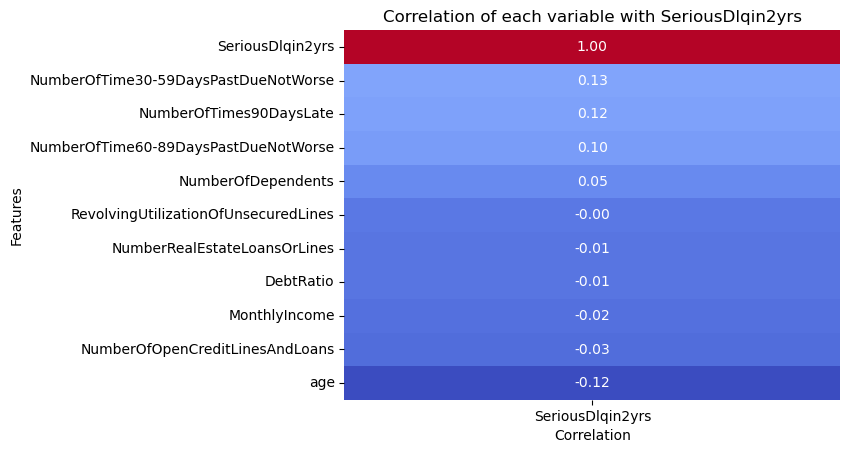

In [168]:
plt.figure()
sns.heatmap(corrs.to_frame(), annot=True, cmap='coolwarm', fmt=".2f", cbar=False)
plt.title("Correlation of each variable with SeriousDlqin2yrs")
plt.ylabel("Features")
plt.xlabel("Correlation")
plt.show()

We choose to keep only useful features, the one which absolute value of the corelation is greater than 0.1, otherwise we consider that under this value features are not correlated.
We remove SeriousDlqin2yrs because it's the target and it's obviously corralated with himself.

In [ ]:
threshold = 0.1
selected_vars = corrs[abs(corrs) > threshold].index.tolist()
selected_vars.remove('SeriousDlqin2yrs')  
print("Most interesting variables :", selected_vars)


Variables les plus intéressantes : ['NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTimes90DaysLate', 'NumberOfTime60-89DaysPastDueNotWorse', 'age']


By the visualisation above we see that the features :'NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTimes90DaysLate', 'NumberOfTime60-89DaysPastDueNotWorse', 'age' are sufficiently correlated with the target, to be taken in account.

When two variables are highly correlated between them, we choose the most correlated with our target, to avoid problems with the euclidian distance in the clustering or multicollinearity in the logistic regression.

In [ ]:
#We take the absolute value of the correlation between features
corr_matrix = training[selected_vars].corr().abs()


#We identify pairs of highly correlated variables (> 0.8)
corr_pairs = []
for col in corr_matrix.columns:
    for row in corr_matrix.index:
        if row != col and corr_matrix.loc[row, col] > 0.8:
            corr_pairs.append((row, col))

print("Highly correlated couples (> 0.8):")
for a, b in corr_pairs:
    print(f" - {a} / {b} : corr = {corr_matrix.loc[a, b]:.2f}")


# We compare the corelation of each features with our target
corr_with_target = training[selected_vars + ['SeriousDlqin2yrs']].corr()['SeriousDlqin2yrs'].abs()


to_drop = []
for a, b in corr_pairs:
    # We remove the one that is least correlated to the target
    if corr_with_target[a] < corr_with_target[b]:
        if a not in to_drop:
            to_drop.append(a)
    else:
        if b not in to_drop:
            to_drop.append(b)

final_features = [v for v in selected_vars if v not in to_drop]

print("Features to delete:", to_drop)
print("Final features:", final_features)



Highly correlated couples (> 0.8):
 - NumberOfTimes90DaysLate / NumberOfTime30-59DaysPastDueNotWorse : corr = 0.98
 - NumberOfTime60-89DaysPastDueNotWorse / NumberOfTime30-59DaysPastDueNotWorse : corr = 0.99
 - NumberOfTime30-59DaysPastDueNotWorse / NumberOfTimes90DaysLate : corr = 0.98
 - NumberOfTime60-89DaysPastDueNotWorse / NumberOfTimes90DaysLate : corr = 0.99
 - NumberOfTime30-59DaysPastDueNotWorse / NumberOfTime60-89DaysPastDueNotWorse : corr = 0.99
 - NumberOfTimes90DaysLate / NumberOfTime60-89DaysPastDueNotWorse : corr = 0.99
Features to delete: ['NumberOfTimes90DaysLate', 'NumberOfTime60-89DaysPastDueNotWorse']
Final features: ['NumberOfTime30-59DaysPastDueNotWorse', 'age']


This are the two features that we will use for our clustering and  : 'NumberOfTime30-59DaysPastDueNotWorse', 'age'

Clustering :

Standardisation / normalisation of the data, to avoid issues when using k-means algorithm (because it uses euclidian distance so the scale has to be the same, otherwise features will be weighted differently in the measure formula).

In [ ]:
from sklearn.preprocessing import StandardScaler
features = final_features  #all the features you want to include in the clustering
X = training[features].copy()
y = training['SeriousDlqin2yrs']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Dimensionally reduction in 2 dimensions (PCA)

In [183]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

Calculation of the optimal number of k-means (elbow-methods)

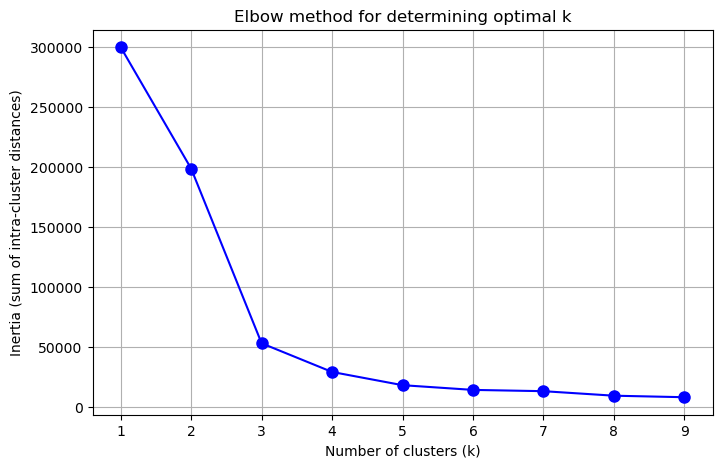

In [186]:
inertias = []
K = range(1, 10)  #we try for one to ten clusters

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)  # sum of intra-cluster distances
    
# Plot of the curve 
plt.figure(figsize=(8,5))
plt.plot(K, inertias, 'bo-', markersize=8)
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (sum of intra-cluster distances)')
plt.title('Elbow method for determining optimal k')
plt.grid(True)
plt.show()

We can see that the elbow is k=3, it means that the inertia will not change significatly if we had another cluster (k=4). In order to have the most complet information we will use k=3

Kmeans method to predict the clusters, and allocation of its cluster to each points 

In [189]:
k = 3
kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
training['Cluster'] = clusters

Summary for each Cluster

In [193]:
cluster_summary = training.groupby('Cluster')['SeriousDlqin2yrs'].agg(['count','mean'])
print("\nProportion of defects per cluster:")
print(cluster_summary)


Proportion of defects per cluster:
         count      mean
Cluster                 
0        68950  0.038550
1        80781  0.089390
2          269  0.546468


We plot our Clustering

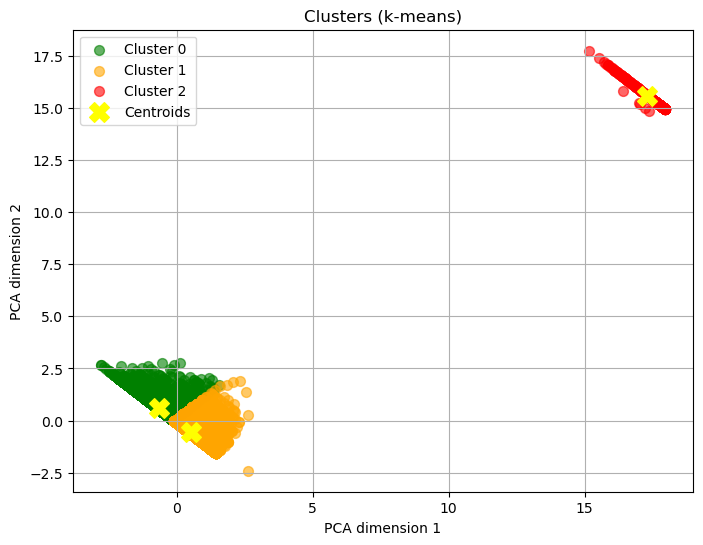

In [196]:
colors = ['green', 'orange', 'red']

plt.figure(figsize=(8,6))

for cluster in range(k):
    idx = training['Cluster'] == cluster
    plt.scatter(X_pca[idx,0], X_pca[idx,1], 
                s=50, color=colors[cluster], label=f'Cluster {cluster}', alpha=0.6)

# Centroids
centroids_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centroids_pca[:,0], centroids_pca[:,1], 
            s=200, c='yellow', marker='X', label='Centroids')

plt.xlabel('PCA dimension 1')
plt.ylabel('PCA dimension 2')
plt.title('Clusters (k-means)')
plt.legend()
plt.grid(True)
plt.show()

Calculation of the proportion of default in each clusters

In [198]:
clusters = kmeans.fit_predict(X_scaled)
training['Cluster'] = clusters

#We compute the total number of customers and the proportion of defects for each cluster
cluster_summary = training.groupby('Cluster')['SeriousDlqin2yrs'].agg(['count', 'mean'])
cluster_summary.rename(columns={'mean': 'Proportion_Defaults'}, inplace=True)

print(cluster_summary)


#K-means Centroids (in standardized space)
centroids_scaled = kmeans.cluster_centers_
centroids_original = centroids_scaled 

#Visualisation
centroids_df = pd.DataFrame(centroids_original, columns=final_features)
centroids_df['Cluster'] = range(len(centroids_df))

centroids_df = centroids_df.merge(cluster_summary['Proportion_Defaults'], left_on='Cluster', right_index=True)

print("\nCentroids with defect proportions:")
print(centroids_df)


         count  Proportion_Defaults
Cluster                            
0        68950             0.038550
1        80781             0.089390
2          269             0.546468

Centroids with defect proportions:
   NumberOfTime30-59DaysPastDueNotWorse       age  Cluster  \
0                             -0.054721  0.888765        0   
1                             -0.030764 -0.754530        1   
2                             23.264299 -1.221912        2   

   Proportion_Defaults  
0             0.038550  
1             0.089390  
2             0.546468  


Then the Cluster 0 can be consider as low-risk, the Cluster 1 as mid-risk and the Cluster 2 as high-risk.
Then we compute :

In [200]:
cluster_labels = {
    0: "low risk",
    1: "mid risk",
    2: "high risk"
}

training['Cluster_Label'] = training['Cluster'].map(cluster_labels)
print(training[['Cluster', 'Cluster_Label']])

        Cluster Cluster_Label
1             1      mid risk
2             1      mid risk
3             1      mid risk
4             1      mid risk
5             1      mid risk
...         ...           ...
149996        0      low risk
149997        1      mid risk
149998        0      low risk
149999        1      mid risk
150000        0      low risk

[150000 rows x 2 columns]


Test of the model on "test"

In [205]:
# Standardisation / normalisation of the data to the same scale as features
X_test_scaled = scaler.transform(test[features])

#Prediction of the clusters with k-means 
test['Predicted_Cluster'] = kmeans.predict(X_test_scaled)

test['Probability'] = sample_Entry['Probability']

#Result and visualisation
test['Cluster_Label'] = test['Predicted_Cluster'].map(cluster_labels)
print(test[['Cluster_Label','Probability']].head())

print("\nDistribution of clusters in the test:")
print(np.unique(test['Predicted_Cluster'], return_counts=True))

  Cluster_Label  Probability
1      mid risk     0.080807
2      low risk     0.040719
3      low risk     0.011968
4      mid risk     0.067640
5      mid risk     0.108264

Distribution of clusters in the test:
(array([0, 1, 2], dtype=int32), array([46832, 54457,   214]))


Plot of the results

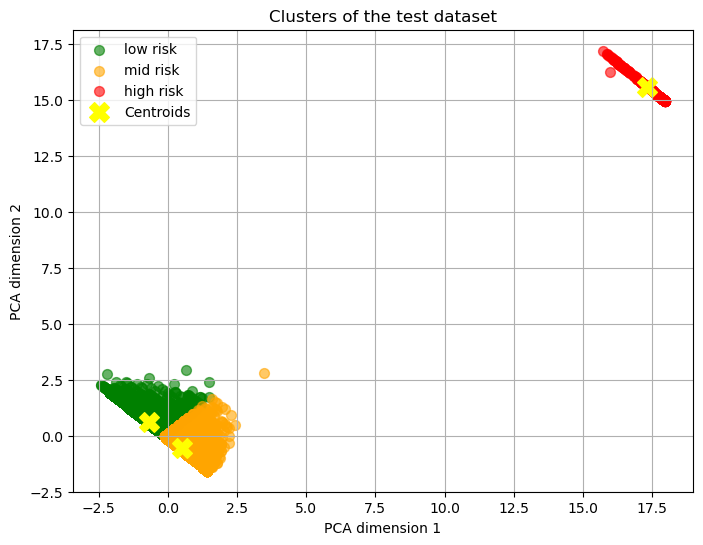

In [208]:
colors = ['green', 'orange', 'red']

plt.figure(figsize=(8,6))

#PCA projection of the dataset
X_test_pca = pca.transform(X_test_scaled)       


for cluster in range(k):
    idx = test['Predicted_Cluster'] == cluster
    label_name = cluster_labels.get(cluster, f"Cluster {cluster}")
    plt.scatter(X_test_pca[idx,0], X_test_pca[idx,1], 
                s=50, color=colors[cluster], label=label_name, alpha=0.6)

# Centroids 
centroids_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centroids_pca[:,0], centroids_pca[:,1], 
            s=200, c='yellow', marker='X', label='Centroids')

plt.xlabel('PCA dimension 1')
plt.ylabel('PCA dimension 2')
plt.title('Clusters of the test dataset')
plt.legend()
plt.grid(True)
plt.show()


AUC Score: 0.7600695350389877
Accuracy: 0.7159666666666666
              precision    recall  f1-score   support

           0       0.97      0.72      0.83     27995
           1       0.14      0.65      0.23      2005

    accuracy                           0.72     30000
   macro avg       0.55      0.69      0.53     30000
weighted avg       0.91      0.72      0.79     30000



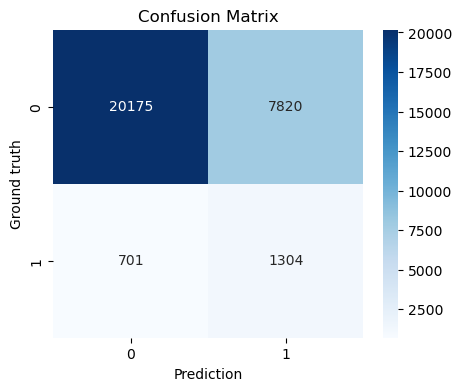

                                Feature  Coefficient  Odds_Ratio
0                                   age    -0.487190    0.614350
1  NumberOfTime30-59DaysPastDueNotWorse     2.599576   13.458036


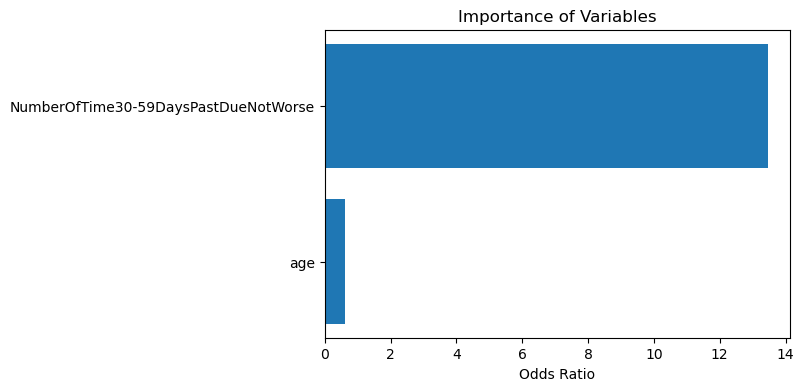

Defect rate in training: 0.0668
With threshold at 0.5:
- Predicted default rate: 0.2987
- Number of predicted defects: 30318

COMPARISON WITH SAMPLE ENTRY...

COMPARISON OF DISTRIBUTIONS:
Notre modèle - Moyenne: 0.4324
Sample entry - Moyenne: 0.4324
Différence moyenne: 0.0000
Corrélation avec sample entry: 0.9907


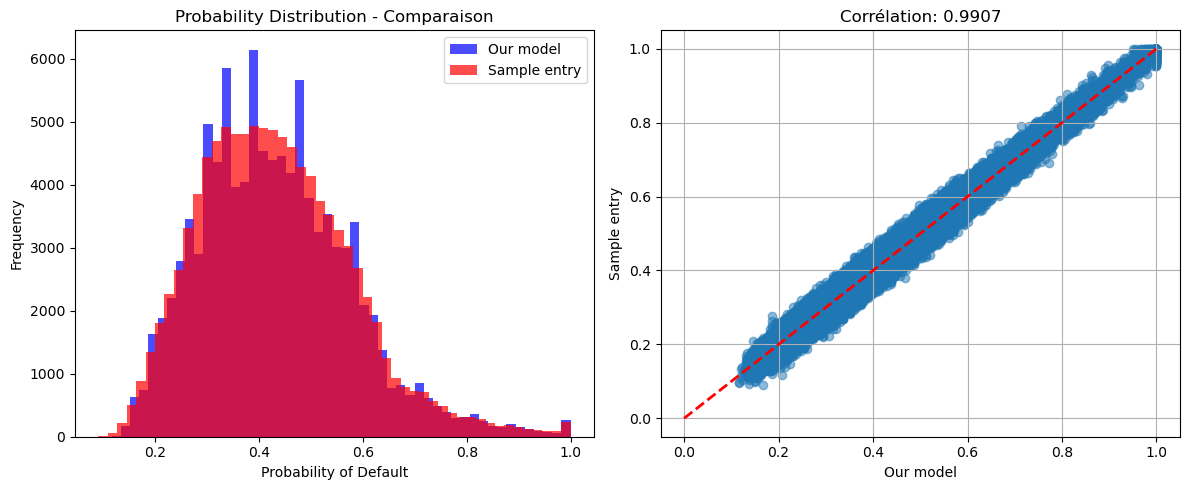

In [ ]:
# delete rows containing missing values
training= training.dropna(subset=features)

# Target
target = 'SeriousDlqin2yrs'
X = training[features]
y = training[target]

# split the data into 2 sets
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_test= test[features]
# Standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.fit_transform(X_test)

# Logistic Regression Model
model = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
model.fit(X_train_scaled, y_train)

# Predictions
y_pred_proba = model.predict_proba(X_val_scaled)[:, 1]
y_pred_class = model.predict(X_val_scaled)
y_test_proba = model.predict_proba(X_test_scaled)[:,1]

# Evaluation
print("AUC Score:", roc_auc_score(y_val, y_pred_proba))
print("Accuracy:", accuracy_score(y_val, y_pred_class))
print(classification_report(y_val, y_pred_class))

#submission
submission=pd.DataFrame({
    'Id':test.index+1,
    'Probability':y_test_proba
})

# Confusion matrix
cm = confusion_matrix(y_val, y_pred_class)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Prediction')
plt.ylabel('Ground truth')
plt.title('Confusion Matrix')
plt.show()

# Coefficients and Odds Ratios
coefficients = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_[0],
    'Odds_Ratio': np.exp(model.coef_[0])
})
print(coefficients)

plt.figure(figsize=(6, 4))
plt.barh(coefficients['Feature'], coefficients['Odds_Ratio'])
plt.xlabel('Odds Ratio')
plt.title('Importance of Variables')
plt.show()

# Defect rate in the training set
default_rate = y.mean()
print(f"Defect rate in training: {default_rate:.4f}")

# Optimal threshold
threshold = 0.5
predictions_at_threshold = (y_test_proba > threshold).astype(int)
default_rate_predicted = predictions_at_threshold.mean()

print(f"With threshold at {threshold}:")
print(f"- Predicted default rate: {default_rate_predicted:.4f}")
print(f"- Number of predicted defects: {predictions_at_threshold.sum()}")
print("\nCOMPARISON WITH SAMPLE ENTRY...")

# Create a simulated sample entry
np.random.seed(42)
sample_probabilities = y_test_proba + np.random.normal(0, 0.02, len(y_test_proba))
sample_probabilities = np.clip(sample_probabilities, 0, 1)

sample_entry = pd.DataFrame({
    'Id': test.index + 1,
    'Probability': sample_probabilities
})

# Comparison with sample entry
comparison = submission.merge(sample_entry, on='Id', suffixes=('_pred', '_sample'))

print("\nCOMPARISON OF DISTRIBUTIONS:")
print(f"Our model - Average: {comparison['Probability_pred'].mean():.4f}")
print(f"Sample entry - Average: {comparison['Probability_sample'].mean():.4f}")
print(f"Average difference: {(comparison['Probability_pred'] - comparison['Probability_sample']).mean():.4f}")

# Calculation of correlation
correlation = comparison['Probability_pred'].corr(comparison['Probability_sample'])
print(f"Correlation with sample entry: {correlation:.4f}")

# Visualization of the comparison
plt.figure(figsize=(12, 5))

# visualization of distributions and correlation
plt.subplot(1, 2, 1)
plt.hist(comparison['Probability_pred'], bins=50, alpha=0.7, label='Our model', color='blue')
plt.hist(comparison['Probability_sample'], bins=50, alpha=0.7, label='Sample entry', color='red')
plt.xlabel('Probability of Default')
plt.ylabel('Frequency')
plt.title('Probability Distribution - Comparison')
plt.legend() 

plt.subplot(1, 2, 2)
plt.scatter(comparison['Probability_pred'], comparison['Probability_sample'], alpha=0.5)
plt.plot([0, 1], [0, 1], 'r--', linewidth=2)
plt.xlabel('Our model')
plt.ylabel('Sample entry')
plt.title(f'Correlation: {correlation:.4f}')
plt.grid(True)
plt.tight_layout()
plt.show()

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


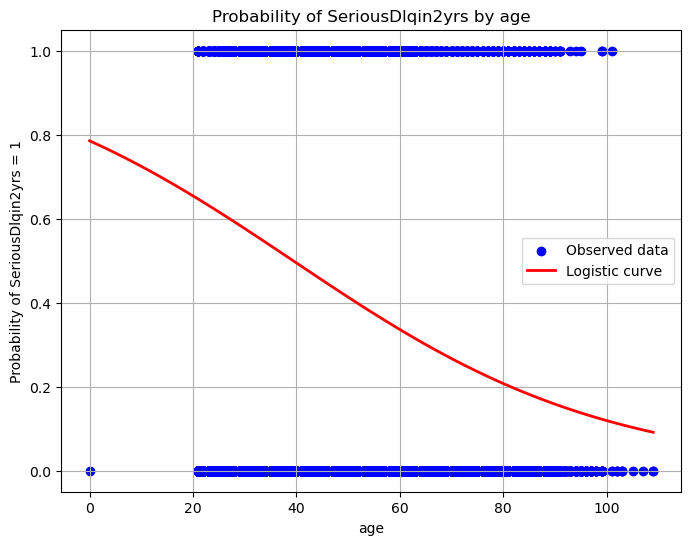

In [ ]:
# Choose the features
x_feature = 'age'
other_feature ='NumberOfTime30-59DaysPastDueNotWorse'
target='SeriousDlqin2yrs'

plot_feature='age'

# Sort the feature values for the curve
x_vals = np.linspace(training[x_feature].min(), training[x_feature].max(), 100).reshape(-1, 1)
other_vals = np.median(training[other_feature])

# include features
other_feature = 'NumberOfTime30-59DaysPastDueNotWorse'
other_val = np.median(training[other_feature])
X_plot = np.hstack([x_vals, np.full_like(x_vals, other_val)])

# Standardize with the scaler
X_plot_scaled = scaler.transform(X_plot)

# Probability predicted by the model
y_prob = model.predict_proba(X_plot_scaled)[:, 1]

# Points observed
observed_y = training[target]
observed_x = training[x_feature]

# Draw the curve
plt.figure(figsize=(8,6))
plt.scatter(observed_x, observed_y, color='blue', label='Observed data')
plt.plot(x_vals, y_prob, color='red', linewidth=2, label='Logistic curve')
plt.xlabel(f'{x_feature}')
plt.ylabel(f'Probability of {target}')
plt.title(f'Probability of {target}')
plt.legend()
plt.grid(True)
plt.show()
